In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import timm
from sklearn.preprocessing import StandardScaler, LabelEncoder  # NEW: for metadata

DATA_DIR = Path("/kaggle/input/competitions/siim-isic-melanoma-classification")
CSV_PATH = DATA_DIR / "train.csv"
IMAGE_DIR = DATA_DIR / "jpeg/train"

print("CSV exists:",          CSV_PATH.exists())
print("Image folder exists:", IMAGE_DIR.exists())
print("CUDA available:",      torch.cuda.is_available())

CSV exists: True
Image folder exists: True
CUDA available: True


In [2]:
df = pd.read_csv(CSV_PATH)  # load Kaggle training metadata

print(df.head())
print(df.columns)
print("\nClass distribution:")
print(df["target"].value_counts())

     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  
0   unknown           benign       0  
1   unknown           benign       0  
2     nevus           benign       0  
3   unknown           benign       0  
4   unknown           benign       0  
Index(['image_name', 'patient_id', 'sex', 'age_approx',
       'anatom_site_general_challenge', 'diagnosis', 'benign_malignant',
       'target'],
      dtype='object')

Class distribution:
target
0    32542
1      584
Name: count, dtype: int64


In [3]:
# --- Metadata preprocessing ---

meta_df = df.copy()

# Sex: male -> 1, female -> 0, missing -> 0.5
meta_df["sex"] = meta_df["sex"].map({"male": 1, "female": 0}).fillna(0.5)

# Age: normalise to 0-1, fill missing with median
meta_df["age_approx"] = meta_df["age_approx"].fillna(meta_df["age_approx"].median())
meta_df["age_approx"] = (meta_df["age_approx"] - meta_df["age_approx"].min()) / \
                         (meta_df["age_approx"].max() - meta_df["age_approx"].min())

# Anatomical site: one-hot encode
meta_df["anatom_site_general_challenge"] = \
    meta_df["anatom_site_general_challenge"].fillna("unknown")
site_dummies = pd.get_dummies(
    meta_df["anatom_site_general_challenge"], prefix="site"
).astype(float)  # FIXED: force to float, not bool

meta_df = pd.concat([meta_df, site_dummies], axis=1)

META_FEATURES = ["sex", "age_approx"] + list(site_dummies.columns)

# Ensure all feature columns are float
meta_df[META_FEATURES] = meta_df[META_FEATURES].astype(float)

print("Metadata features:", META_FEATURES)
print("Total features:", len(META_FEATURES))
print(meta_df[META_FEATURES].dtypes)


Metadata features: ['sex', 'age_approx', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_unknown', 'site_upper extremity']
Total features: 9
sex                     float64
age_approx              float64
site_head/neck          float64
site_lower extremity    float64
site_oral/genital       float64
site_palms/soles        float64
site_torso              float64
site_unknown            float64
site_upper extremity    float64
dtype: object


In [4]:
from sklearn.model_selection import train_test_split

# Split on meta_df so metadata stays aligned with the image dataframe
train_df, val_df = train_test_split(
    meta_df,
    test_size=0.2,
    stratify=meta_df["target"],
    random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:",   len(val_df))
print("\nTrain class distribution:")
print(train_df["target"].value_counts())

Train size: 26500
Val size: 6626

Train class distribution:
target
0    26033
1      467
Name: count, dtype: int64


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),  # Must be after ToTensor
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_name = row["image_name"]
        label = int(row["target"])

        image_path = self.image_dir / f"{image_name}.jpg"
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [7]:
train_set = MelanomaDataset(train_df, IMAGE_DIR, transform=train_transform)
val_set   = MelanomaDataset(val_df,   IMAGE_DIR, transform=val_transform)

print("Train samples:", len(train_set))
print("Val samples:",   len(val_set))

Train samples: 26500
Val samples: 6626


In [8]:
train_loader = DataLoader(
    train_set,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_set,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 415
Validation batches: 104


In [9]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
First 10 labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [10]:
class MelanomaModel(nn.Module):
    def __init__(self, model_name='efficientnet_b3', n_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=True, num_classes=0, global_pool='avg'
        )

        # Freeze backbone — only train the head for first few epochs
        for param in self.backbone.parameters():
            param.requires_grad = False

        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(p=0.5),              # increased from 0.3
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),              # increased from 0.2
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # NEW
model = MelanomaModel(n_classes=2).to(device)  # NEW

print("Using device:", device)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Using device: cuda


In [12]:
from torch import optim

NUM_EPOCHS     = 5
LEARNING_RATE  = 1e-4
UNFREEZE_EPOCH = 3   # backbone unfreezes after this many epochs

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=1e-4   # stronger weight decay vs 1e-5 before
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# Weighted loss tells the model to pay more attention to melanoma cases
# without repeating the images
pos_ratio = (train_df["target"] == 0).sum() / (train_df["target"] == 1).sum()
weights   = torch.tensor([1.0, pos_ratio], dtype=torch.float32)
weights   = weights / weights.sum() * 2
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

print(f"Positive class weight ratio: {pos_ratio:.1f}x")
print("Class weights:", weights)

Positive class weight ratio: 55.7x
Class weights: tensor([0.0352, 1.9648])


In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        # FIXED: zero_grad MUST come before the forward pass, not after backward
        optimizer.zero_grad()

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = running_loss / len(loader)
    val_acc = accuracy_score(all_labels, all_preds)

    return val_loss, val_acc, all_labels, all_preds, all_probs

In [15]:
train_losses, val_losses, val_accuracies, val_aucs = [], [], [], []
best_auc = 0.0

for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, y_true, y_pred, y_prob = validate(model, val_loader, criterion, device)
    scheduler.step()

    val_auc = roc_auc_score(y_true, y_prob)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_aucs.append(val_auc)

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_model_efficientnet_b3.pth")
        print(f"  -> New best AUC: {best_auc:.4f} — model saved.")

print(f"\nTraining complete. Best Val AUC: {best_auc:.4f}")


Epoch 01/5 | Train Loss: 0.6263 | Val Loss: 0.5949 | Val Acc: 0.9245 | Val AUC: 0.7467
  -> New best AUC: 0.7467 — model saved.
Epoch 02/5 | Train Loss: 0.5843 | Val Loss: 0.5693 | Val Acc: 0.7315 | Val AUC: 0.7860
  -> New best AUC: 0.7860 — model saved.
Epoch 03/5 | Train Loss: 0.5655 | Val Loss: 0.5483 | Val Acc: 0.7626 | Val AUC: 0.7935
  -> New best AUC: 0.7935 — model saved.
Epoch 04/5 | Train Loss: 0.5433 | Val Loss: 0.5478 | Val Acc: 0.7033 | Val AUC: 0.8056
  -> New best AUC: 0.8056 — model saved.
Epoch 05/5 | Train Loss: 0.5437 | Val Loss: 0.5360 | Val Acc: 0.7694 | Val AUC: 0.8018

Training complete. Best Val AUC: 0.8056


In [16]:
# Load best image model and get predictions
model.load_state_dict(torch.load(
    "/kaggle/input/datasets/louisilett/version-7-output/best_model_efficientnet_b3.pth",
    map_location=device
))
model.eval()
print("Model loaded successfully")

image_probs, true_labels, image_preds = [], [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)
        image_probs.extend(probs.cpu().numpy())
        image_preds.extend(preds.cpu().numpy())
        true_labels.extend(labels.numpy())

image_probs  = np.array(image_probs)
image_preds  = np.array(image_preds)
true_labels  = np.array(true_labels)
image_auc    = roc_auc_score(true_labels, image_probs)
print(f"Image model AUC: {image_auc:.4f}")


Model loaded successfully
Image model AUC: 0.8455


In [17]:
# Metadata model definition and datasets
class MetadataModel(nn.Module):
    def __init__(self, input_dim, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        return self.net(x)


class MetadataDataset(Dataset):
    def __init__(self, dataframe, feature_cols):
        self.features = torch.tensor(
            dataframe[feature_cols].values, dtype=torch.float32
        )
        self.labels = torch.tensor(dataframe["target"].values, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


meta_train_ds = MetadataDataset(train_df, META_FEATURES)
meta_val_ds   = MetadataDataset(val_df,   META_FEATURES)

meta_train_loader = DataLoader(meta_train_ds, batch_size=256, shuffle=True)
meta_val_loader   = DataLoader(meta_val_ds,   batch_size=256, shuffle=False)

meta_model = MetadataModel(input_dim=len(META_FEATURES), n_classes=2).to(device)
print(f"Metadata model ready — {sum(p.numel() for p in meta_model.parameters()):,} params")


Metadata model ready — 2,786 params


In [18]:
# Train metadata model
meta_optimizer = torch.optim.AdamW(
    meta_model.parameters(), lr=1e-3, weight_decay=1e-4
)
meta_criterion = nn.CrossEntropyLoss(weight=weights.to(device))
meta_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    meta_optimizer, T_max=30, eta_min=1e-6
)

best_meta_auc = 0.0
META_EPOCHS   = 30

for epoch in range(META_EPOCHS):
    meta_model.train()
    for feats, labels in meta_train_loader:
        feats, labels = feats.to(device), labels.to(device)
        meta_optimizer.zero_grad()
        loss = meta_criterion(meta_model(feats), labels)
        loss.backward()
        meta_optimizer.step()
    meta_scheduler.step()

    meta_model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for feats, labels in meta_val_loader:
            probs = torch.softmax(meta_model(feats.to(device)), dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    meta_auc = roc_auc_score(all_labels, all_probs)
    if meta_auc > best_meta_auc:
        best_meta_auc = meta_auc
        torch.save(meta_model.state_dict(), "best_meta_model.pth")

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{META_EPOCHS} | Meta AUC: {meta_auc:.4f}")

print(f"\nBest Metadata Model AUC: {best_meta_auc:.4f}")


Epoch 05/30 | Meta AUC: 0.6314
Epoch 10/30 | Meta AUC: 0.6577
Epoch 15/30 | Meta AUC: 0.6652
Epoch 20/30 | Meta AUC: 0.6639
Epoch 25/30 | Meta AUC: 0.6663
Epoch 30/30 | Meta AUC: 0.6660

Best Metadata Model AUC: 0.6663


In [19]:
# Load best metadata model and get predictions
meta_model.load_state_dict(torch.load("best_meta_model.pth", map_location=device))
meta_model.eval()

meta_probs = []
with torch.no_grad():
    for feats, labels in meta_val_loader:
        probs = torch.softmax(meta_model(feats.to(device)), dim=1)[:, 1]
        meta_probs.extend(probs.cpu().numpy())

meta_probs = np.array(meta_probs)
meta_auc   = roc_auc_score(true_labels, meta_probs)
print(f"Metadata model AUC: {meta_auc:.4f}")


Metadata model AUC: 0.6663


Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.81      0.89      6509
    Melanoma       0.06      0.68      0.11       117

    accuracy                           0.81      6626
   macro avg       0.53      0.75      0.50      6626
weighted avg       0.98      0.81      0.88      6626


Image model AUC:    0.8455
Metadata model AUC: 0.6663
Ensemble AUC:       0.8493
Improvement:        +0.0038


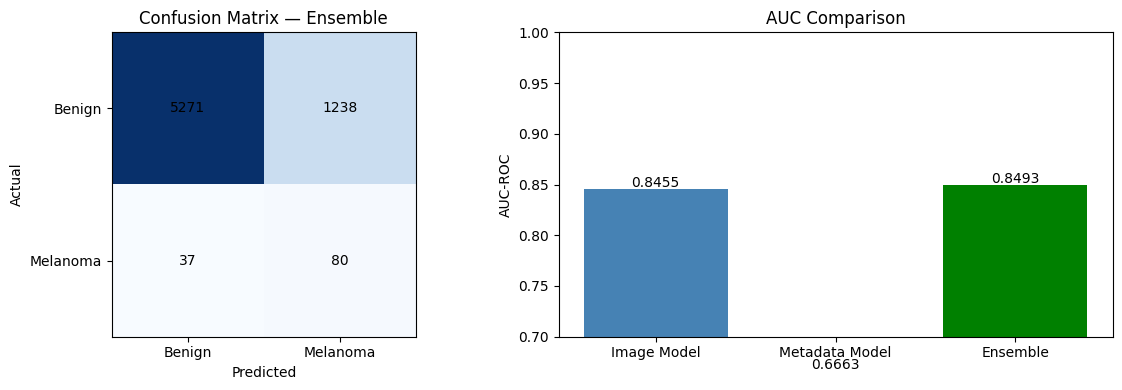

In [20]:
# --- Final results ---

IMAGE_WEIGHT    = 0.8
METADATA_WEIGHT = 0.2
ensemble_probs  = IMAGE_WEIGHT * image_probs + METADATA_WEIGHT * meta_probs
ensemble_auc    = roc_auc_score(true_labels, ensemble_probs)

ensemble_preds = (ensemble_probs >= 0.5).astype(int)
cm = confusion_matrix(true_labels, ensemble_preds)

print("Classification Report:")
print(classification_report(
    true_labels, ensemble_preds, target_names=["Benign", "Melanoma"]
))
print(f"\nImage model AUC:    {image_auc:.4f}")
print(f"Metadata model AUC: {meta_auc:.4f}")
print(f"Ensemble AUC:       {ensemble_auc:.4f}")
print(f"Improvement:        +{ensemble_auc - image_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix — Ensemble")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Benign", "Melanoma"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Benign", "Melanoma"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="black")

axes[1].bar(
    ["Image Model", "Metadata Model", "Ensemble"],
    [image_auc, meta_auc, ensemble_auc],
    color=["steelblue", "tomato", "green"]
)
axes[1].set_title("AUC Comparison")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim([0.7, 1.0])
for i, v in enumerate([image_auc, meta_auc, ensemble_auc]):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()